In [138]:
# ── 0. Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from IPython.display import display


In [139]:
df = pd.read_csv("loan_data.csv")

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [140]:
df.shape

(45000, 14)

In [141]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [142]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [143]:
#check for missing values
print(df.isnull().sum())

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [144]:
#check for duplicates
print(df.duplicated().sum())
#target variable distribution 
print("\n Loan Status Value Counts:")
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).round(3))

0

 Loan Status Value Counts:
loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


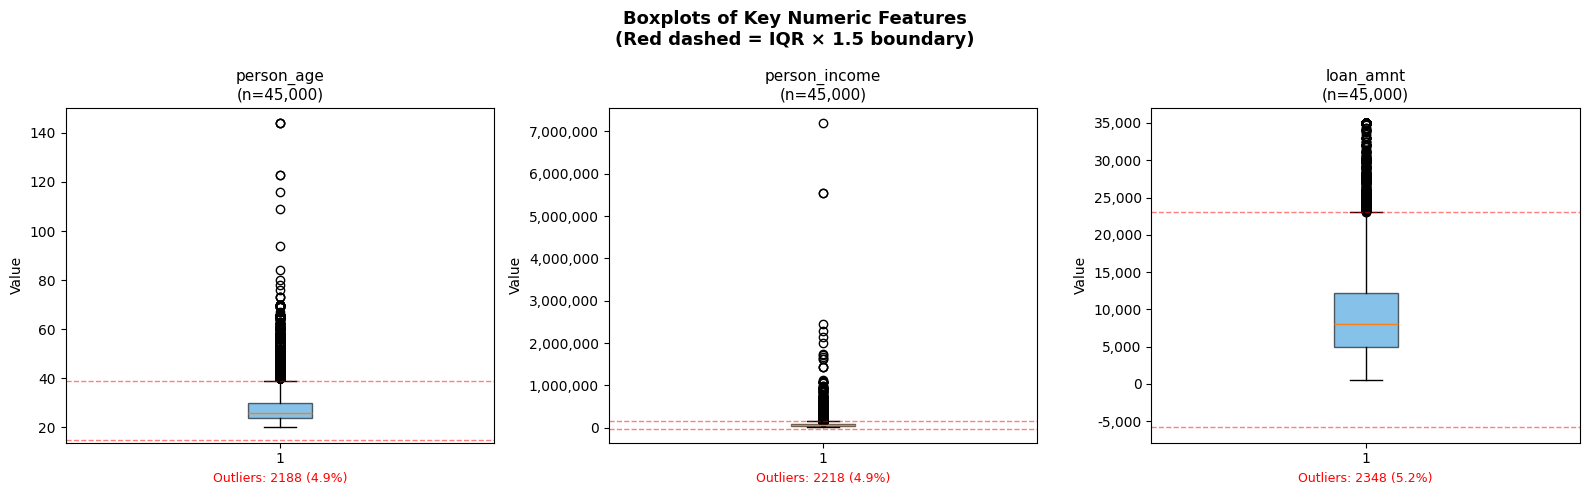

In [145]:
#Outlier detection

key_numeric = ['person_age', 'person_income', 'loan_amnt']
fig , axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(key_numeric):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[i].set_title(f'{col}\n(n={len(data):,})', fontsize=11)
    axes[i].set_ylabel('Value')
    axes[i].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    axes[i].axhline(lower, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].axhline(upper, color='red', linestyle='--', alpha=0.5, linewidth=1)

    outliers = data[(data < lower) | (data > upper)]
    axes[i].set_xlabel(f'Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)',
                       fontsize=9, color='red')

plt.suptitle('Boxplots of Key Numeric Features\n(Red dashed = IQR × 1.5 boundary)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("outliers_new.png", dpi=150)
plt.show()

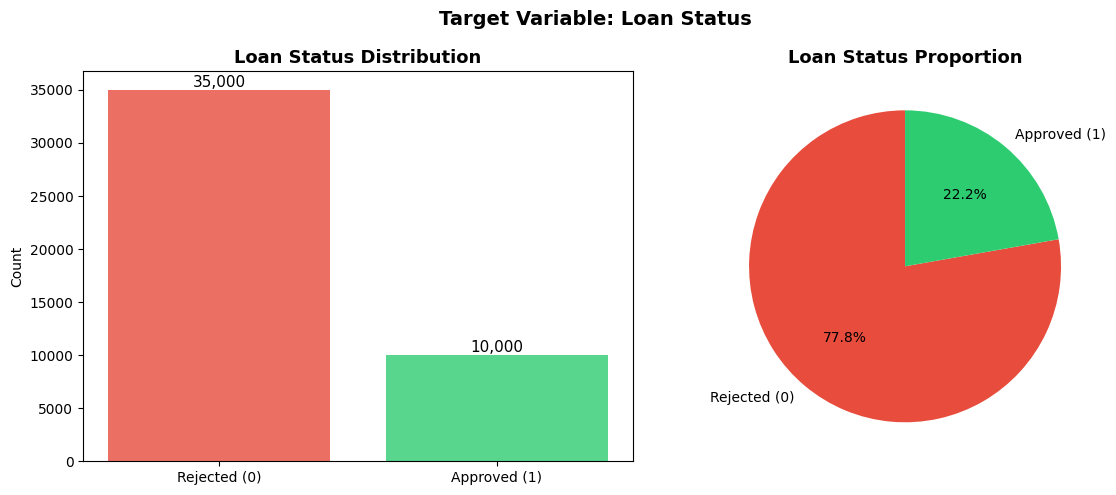

In [146]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

status_counts = df['loan_status'].value_counts()
axes[0].bar(['Rejected (0)', 'Approved (1)'], 
            status_counts.values,
            color=['#e74c3c', '#2ecc71'], 
            alpha=0.8)
axes[0].set_title('Loan Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(status_counts.values, 
            labels=['Rejected (0)', 'Approved (1)'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', 
            startangle=90)
axes[1].set_title('Loan Status Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Loan Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loan_status_distribution.png', dpi=150)
plt.show()

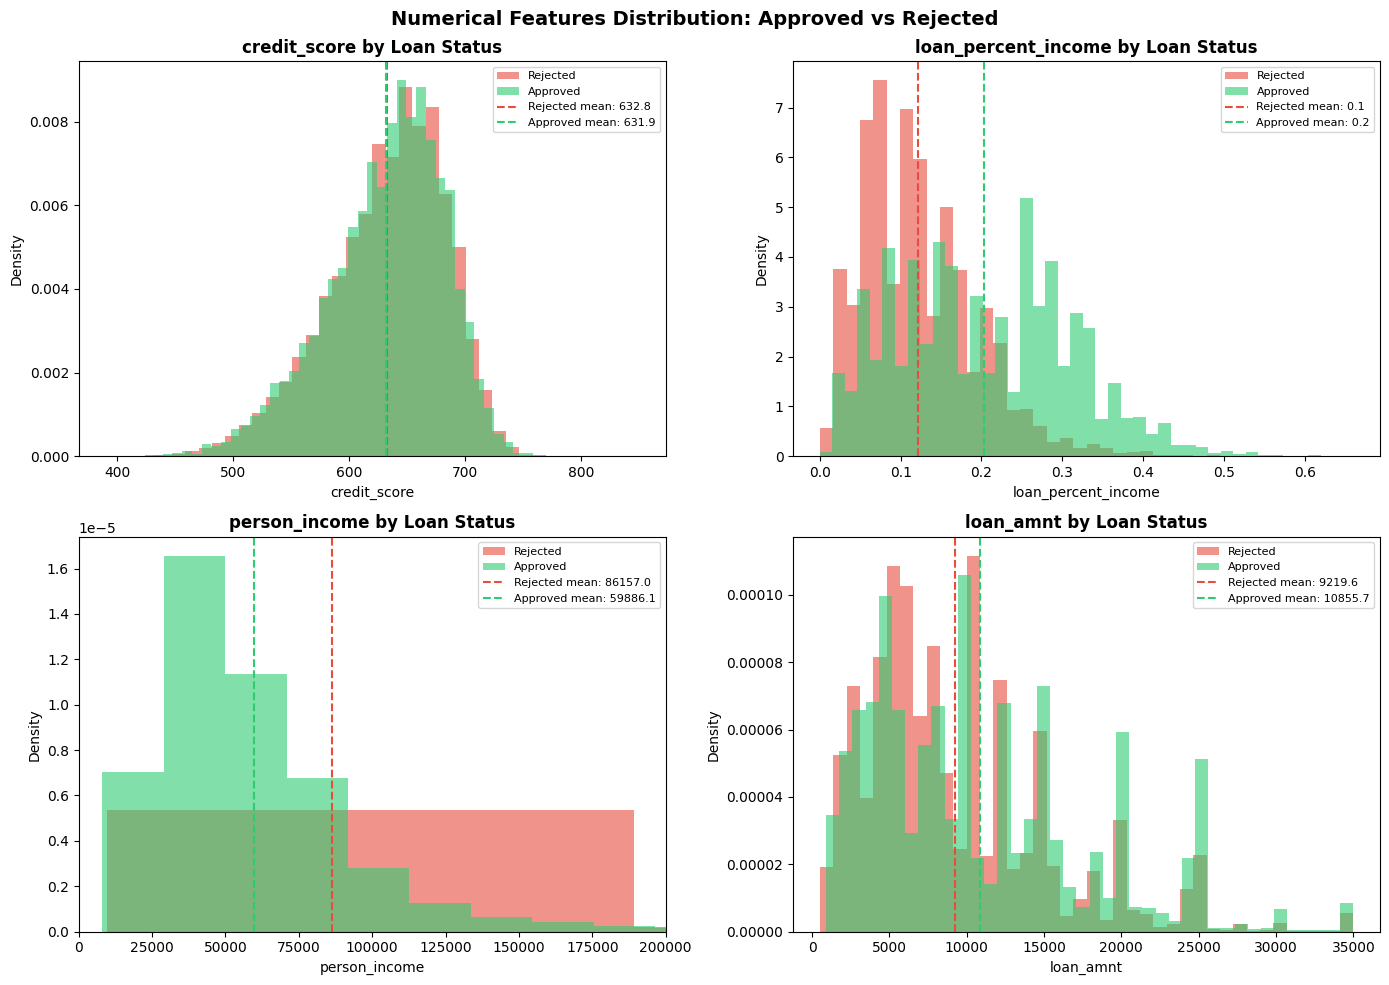

In [147]:
# Numerical Variable Distribution by Loan Status 
num_cols = ['credit_score', 'loan_percent_income', 
            'person_income', 'loan_amnt']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

approved = df[df['loan_status'] == 1]
rejected = df[df['loan_status'] == 0]

for i, col in enumerate(num_cols):
    axes[i].hist(rejected[col], bins=40, alpha=0.6, 
                 color='#e74c3c', label='Rejected', density=True)
    axes[i].hist(approved[col], bins=40, alpha=0.6, 
                 color='#2ecc71', label='Approved', density=True)
    axes[i].set_title(f'{col} by Loan Status', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    if col == 'person_income':
        axes[i].set_xlim(0, 200000)
    # mean lines
    axes[i].axvline(rejected[col].mean(), color='#e74c3c', 
                    linestyle='--', linewidth=1.5,
                    label=f'Rejected mean: {rejected[col].mean():.1f}')
    axes[i].axvline(approved[col].mean(), color='#2ecc71', 
                    linestyle='--', linewidth=1.5,
                    label=f'Approved mean: {approved[col].mean():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Features Distribution: Approved vs Rejected',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distribution.png', dpi=150)
plt.show()

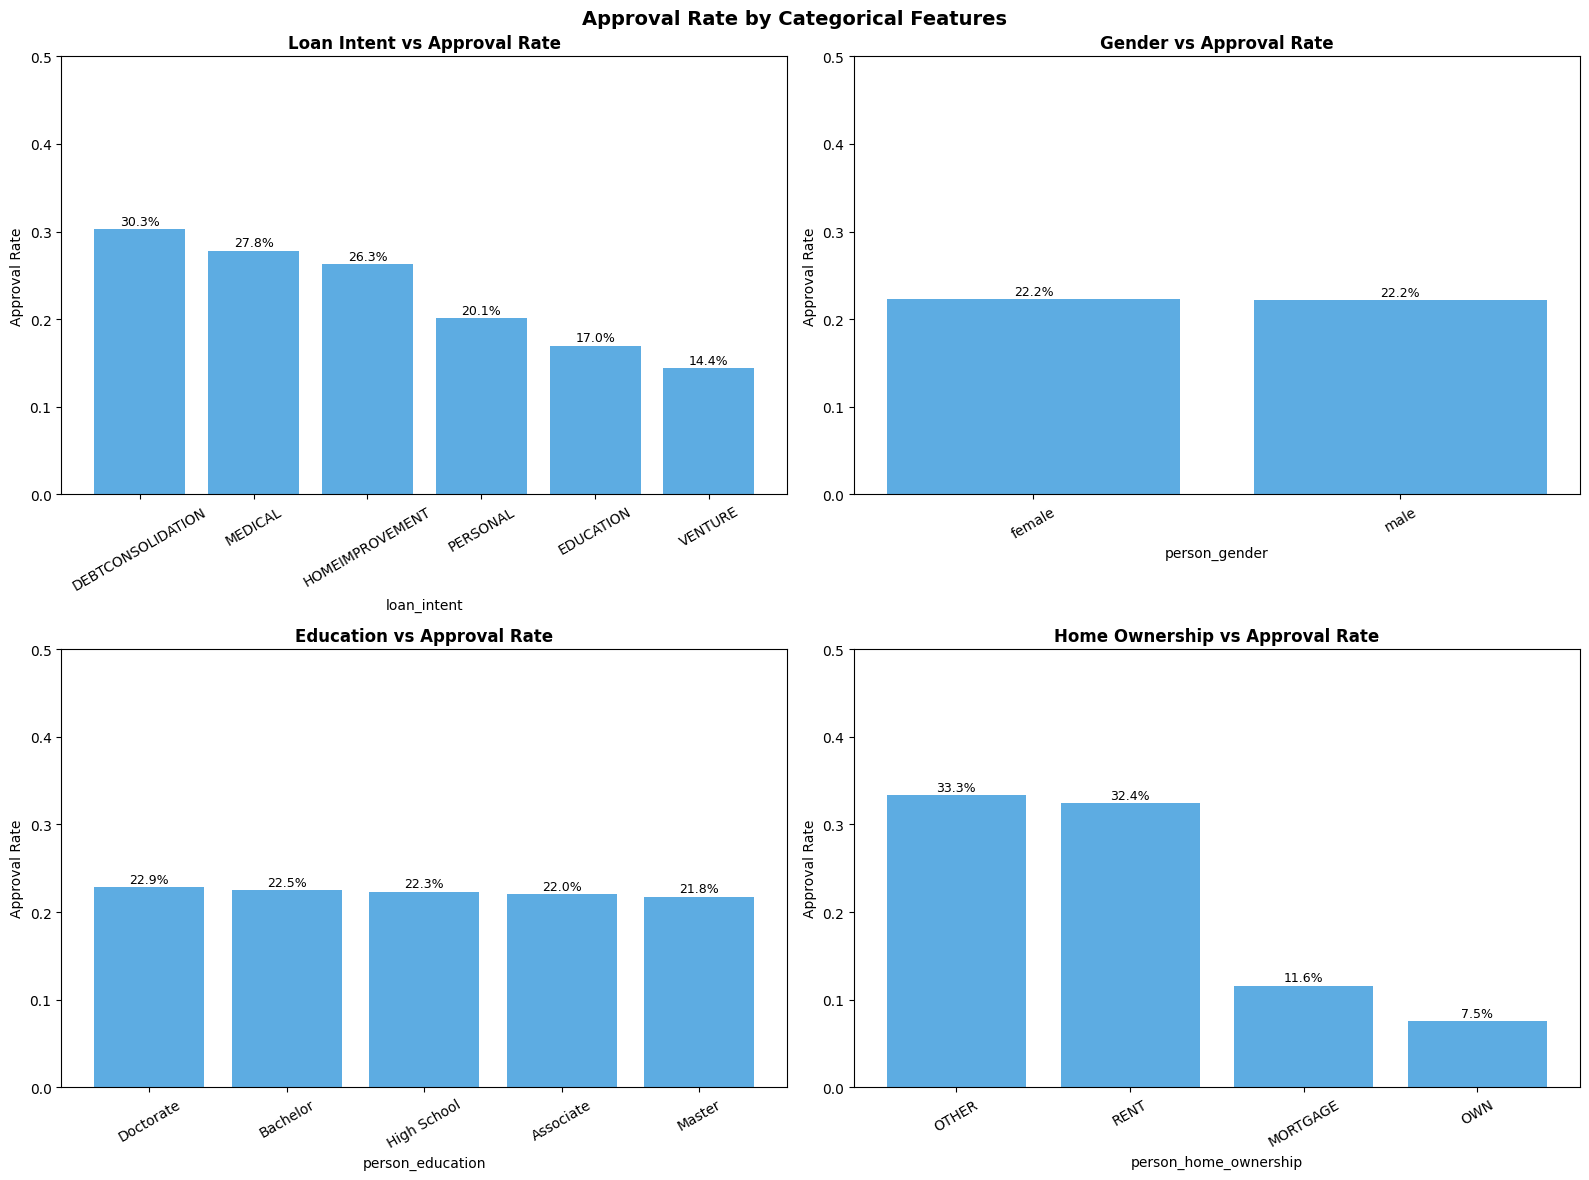

In [148]:
# Categorical Variables Analysis (Sub Q2 & Q3)
cat_cols = ['loan_intent', 'person_gender', 'person_education', 'person_home_ownership']
titles = ['Loan Intent vs Approval Rate',
          'Gender vs Approval Rate',
          'Education vs Approval Rate',
          'Home Ownership vs Approval Rate']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(cat_cols, titles)):
    approval_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    
    bars = axes[i].bar(approval_rate.index, 
                       approval_rate.values,
                       color='#3498db', alpha=0.8)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Approval Rate')
    axes[i].set_xlabel(col)
    axes[i].set_ylim(0, 0.5)
    axes[i].tick_params(axis='x', rotation=30)
    
   
    for bar, val in zip(bars, approval_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.1%}', ha='center', fontsize=9)

plt.suptitle('Approval Rate by Categorical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150)
plt.show()

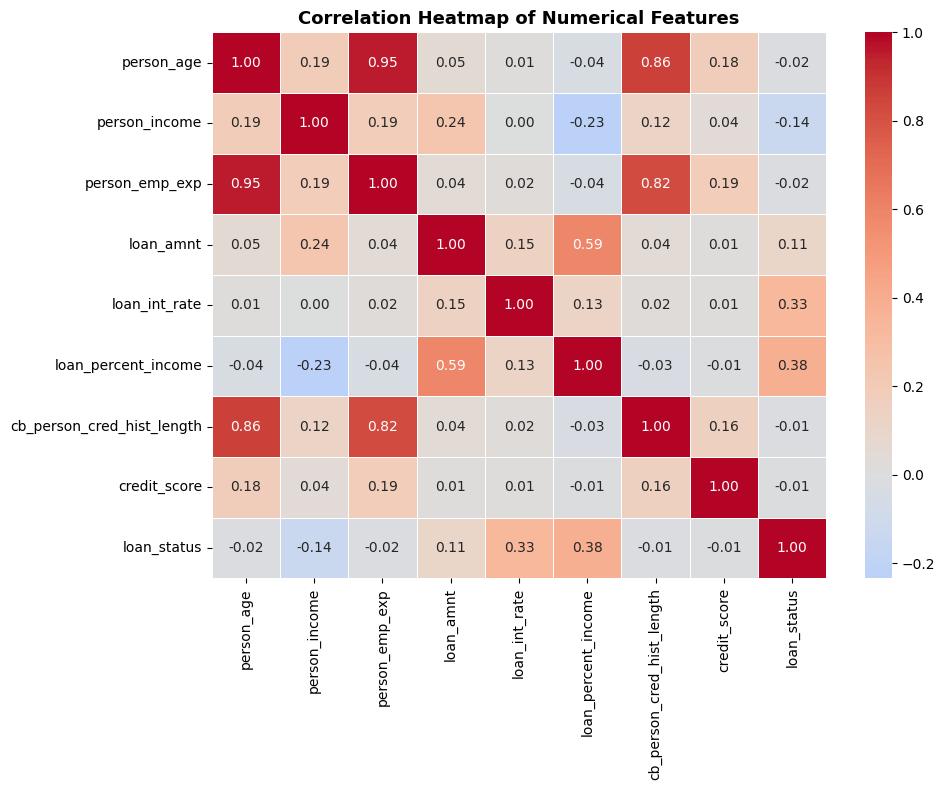

In [149]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

num_df = df[['person_age', 'person_income', 'person_emp_exp',
             'loan_amnt', 'loan_int_rate', 'loan_percent_income',
             'cb_person_cred_hist_length', 'credit_score', 'loan_status']]

corr = num_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)

ax.set_title('Correlation Heatmap of Numerical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [150]:
# Feature Selection

# 1. Loan to Income Ratio
df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']

# 2. Monthly Payment Estimate
df['monthly_payment_estimate'] = df['loan_amnt'] * df['loan_int_rate'] / 100/12

# 3. Income per Employment Year
df['income_per_emp_year'] = df['person_income'] / (df['person_emp_exp'] + 1)

# 4. Debt Burden
df['debt_burden'] = df['loan_amnt'] *df['loan_int_rate'] / 100

# 5. Credit Score Category
def credit_category(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    else:
        return 'Excellent'

df['credit_score_category'] = df['credit_score'].apply(credit_category)

# 6. Age Group
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 40:
        return 'Middle'
    else:
        return 'Senior'

df['age_group'] = df['person_age'].apply(age_group)

# 7. High Risk
df['high_risk_flag'] = ((df['loan_percent_income'] > 0.3) & 
                         (df['credit_score'] < 600)).astype(int)

# 8. Income Credit Ratio
df['income_credit_ratio'] = df['person_income'] / df['credit_score']

# 9. Loan per Credit Year
df['loan_per_credit_year'] = df['loan_amnt'] / (df['cb_person_cred_hist_length'] + 1)

# 10. Experience Ratio
df['experience_ratio'] = df['person_emp_exp'] / (df['person_age'] - 18 + 1)

print("New shape:", df.shape)
print("\nNew columns added:")
new_cols = ['loan_to_income_ratio', 'monthly_payment_estimate', 
            'income_per_emp_year', 'debt_burden', 'credit_score_category',
            'age_group', 'high_risk_flag', 'income_credit_ratio',
            'loan_per_credit_year', 'experience_ratio']
print(df[new_cols].head())

New shape: (45000, 24)

New columns added:
   loan_to_income_ratio  monthly_payment_estimate  income_per_emp_year  \
0              0.486462                467.250000              71948.0   
1              0.081420                  9.283333              12282.0   
2              0.442193                 58.987500               3109.5   
3              0.438855                444.208333              79753.0   
4              0.529221                416.208333              33067.5   

   debt_burden credit_score_category age_group  high_risk_flag  \
0      5607.00                  Poor     Young               1   
1       111.40                  Poor     Young               0   
2       707.85                  Fair     Young               0   
3      5330.50                  Good     Young               0   
4      4994.50                  Fair     Young               1   

   income_credit_ratio  loan_per_credit_year  experience_ratio  
0           128.249554           8750.000000      

In [151]:
# Encoding
from sklearn.preprocessing import LabelEncoder


df_model = df.copy()


ohe_cols = ['person_gender', 'person_home_ownership', 
            'loan_intent', 'previous_loan_defaults_on_file',
            'age_group']
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)
# loan_status is dropped as y 
#age_group_Middle, person_gender_female, and loan_intent_debtconsoliation 
#are dropped by drop_first=True in pd.get_dummies() to avoid multicollinearity 
bool_cols = df_model.select_dtypes(include=['bool']).columns
df_model[bool_cols] =df_model[bool_cols].astype(int)

print(df_model.shape)
print(df_model.columns.tolist())
ohe_result = [col for col in df_model.columns if any(x in col for x in ohe_cols)]
print(df_model[ohe_result].head())


(45000, 31)
['person_age', 'person_education', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status', 'loan_to_income_ratio', 'monthly_payment_estimate', 'income_per_emp_year', 'debt_burden', 'credit_score_category', 'high_risk_flag', 'income_credit_ratio', 'loan_per_credit_year', 'experience_ratio', 'person_gender_male', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_Yes', 'age_group_Senior', 'age_group_Young']
   person_gender_male  person_home_ownership_OTHER  person_home_ownership_OWN  \
0                   0                            0                          0   
1                   0                            0                          1   
2                   0                         

In [152]:
edu_order = {'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4}
credit_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}

df_model['person_education'] = df_model['person_education'].map(edu_order)
df_model['credit_score_category'] = df_model['credit_score_category'].map(credit_order)

print("Final shape:", df_model.shape)
print(df_model[['person_education', 'credit_score_category']].head())

Final shape: (45000, 31)
   person_education  credit_score_category
0                 3                      0
1                 0                      0
2                 0                      1
3                 2                      2
4                 3                      1


In [153]:
df_missing = df_model.copy()

# random switch Yes record to NaN
np.random.seed(42)
yes_idx = df_missing[df_missing['previous_loan_defaults_on_file_Yes'] == 1].index
missing_idx = np.random.choice(yes_idx, size = int(len(yes_idx)*0.6), replace=False)

df_missing.loc[missing_idx, 'previous_loan_defaults_on_file_Yes'] = np.nan

# fill NaN
df_missing['previous_loan_defaults_on_file_Yes'] = df_missing[
    'previous_loan_defaults_on_file_Yes'].fillna(0)

print("Missing values after fillna:", df_missing['previous_loan_defaults_on_file_Yes'].isnull().sum())
print(df_missing['previous_loan_defaults_on_file_Yes'].value_counts())

Missing values after fillna: 0
previous_loan_defaults_on_file_Yes
0.0    35856
1.0     9144
Name: count, dtype: int64


In [154]:
from sklearn.model_selection import train_test_split

#split from df_missing 
x = df_missing.drop(columns=['loan_status'])
y = df_missing['loan_status']

#80/20 split 
x_train , x_test , y_train, y_test = train_test_split(x,y, test_size = 0.2 ,
                                                       random_state= 42 , stratify=y)

print("x_train shape :", x_train.shape)
print("x_test shape :", x_test.shape)
print("\nTrain class distribution:", y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:", y_test.value_counts(normalize=True).round(3))

x_train shape : (36000, 30)
x_test shape : (9000, 30)

Train class distribution: loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64

Test class distribution: loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


In [155]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay)
from xgboost import XGBClassifier
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth= 10,random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100 ,random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, scale_pos_weight= 3.5
                             ,use_label_encoder=False, eval_metric='logloss')
}

results = {} 
for name, model in models.items():
    model.fit(x_train, y_train)
    results[name] = model
    print(f"{name} completed ")

Decision Tree completed 
Random Forest completed 
XGBoost completed 


c:\Users\p0905\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:11:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Decision Tree
  ROC AUC: 0.9222
  PR AUC: 0.8375

              precision    recall  f1-score   support

    Rejected       0.93      0.93      0.93      7000
    Approved       0.76      0.74      0.75      2000

    accuracy                           0.89      9000
   macro avg       0.84      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



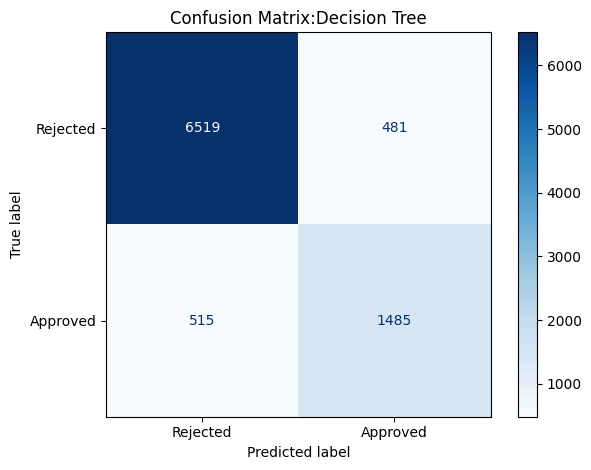

Random Forest
  ROC AUC: 0.9458
  PR AUC: 0.8859

              precision    recall  f1-score   support

    Rejected       0.91      0.98      0.95      7000
    Approved       0.92      0.67      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.92      0.83      0.86      9000
weighted avg       0.92      0.91      0.91      9000



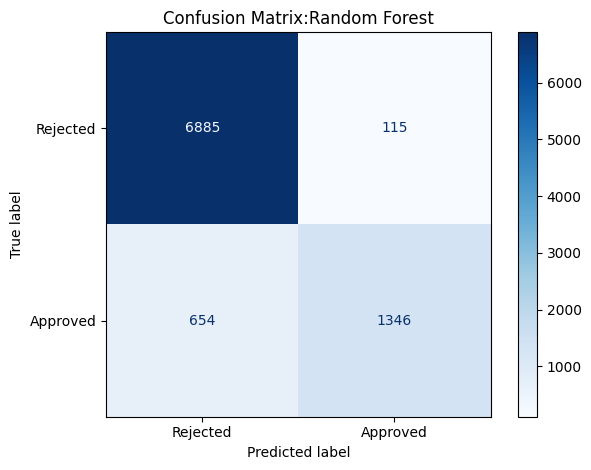

XGBoost
  ROC AUC: 0.9485
  PR AUC: 0.8892

              precision    recall  f1-score   support

    Rejected       0.95      0.91      0.93      7000
    Approved       0.72      0.83      0.77      2000

    accuracy                           0.89      9000
   macro avg       0.83      0.87      0.85      9000
weighted avg       0.90      0.89      0.89      9000



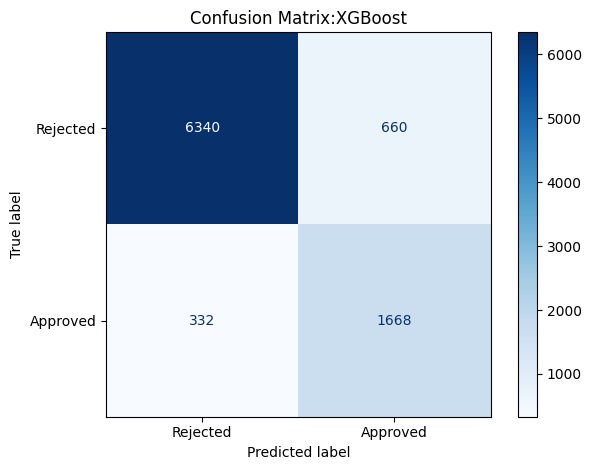

In [156]:
from sklearn.metrics  import ConfusionMatrixDisplay
for name , model in results.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"{name}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  PR AUC: {pr_auc:.4f}")
    print( )
    print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix:'+ name)
    plt.tight_layout()
    plt.savefig(name +'_confusion_matrix.png', dpi=150)
    plt.show()


Threshold Tuning
【Decision Tree】
  Best Threshold : 0.73
  Precision      : 0.8666
  Recall         : 0.6755
  F1             : 0.7592


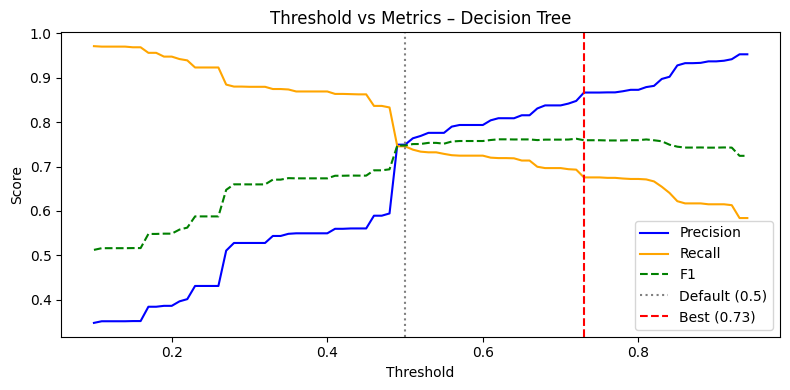

【Random Forest】
  Best Threshold : 0.40
  Precision      : 0.8571
  Recall         : 0.7290
  F1             : 0.7879


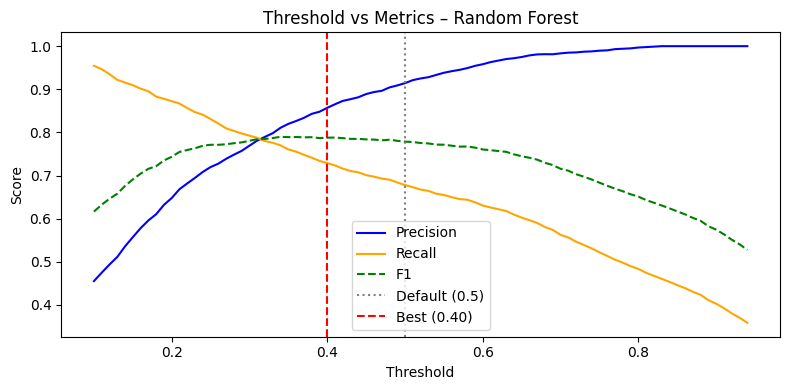

【XGBoost】
  Best Threshold : 0.67
  Precision      : 0.8561
  Recall         : 0.7315
  F1             : 0.7889


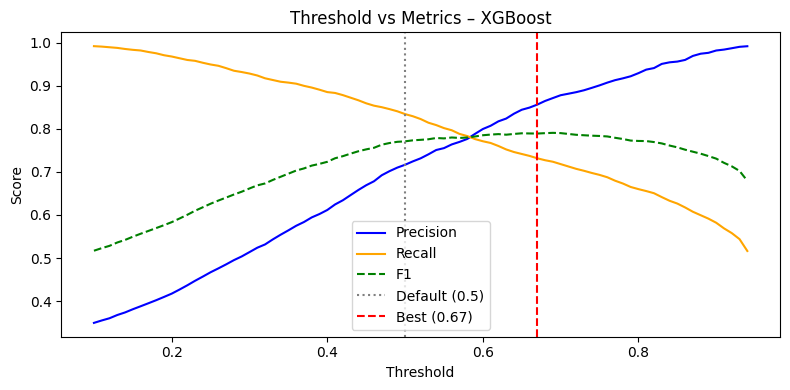

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Threshold Tuning")

for name, model in results.items():
    y_prob = model.predict_proba(x_test)[:, 1]  

    thresholds = np.arange(0.1, 0.95, 0.01)
    records = []

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        p = precision_score(y_test, y_pred_t, zero_division=0)
        r = recall_score(y_test, y_pred_t)
        f = f1_score(y_test, y_pred_t)
        records.append((t, p, r, f))

    results_df = pd.DataFrame(records, columns=['Threshold', 'Precision', 'Recall', 'F1'])

    # Precision >= 0.85 的條件下找 Recall 最高的點
    filtered = results_df[results_df['Precision'] >= 0.85]

    if len(filtered) > 0:
        best_row = filtered.loc[filtered['Recall'].idxmax()]
        print(f"【{name}】")
        print(f"  Best Threshold : {best_row['Threshold']:.2f}")
        print(f"  Precision      : {best_row['Precision']:.4f}")
        print(f"  Recall         : {best_row['Recall']:.4f}")
        print(f"  F1             : {best_row['F1']:.4f}")
    else:
        print(f"【{name}】Can not find suitable threshold where Precision >= 0.85")

    
    plt.figure(figsize=(8, 4))
    plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision', color='blue')
    plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall', color='orange')
    plt.plot(results_df['Threshold'], results_df['F1'], label='F1', color='green', linestyle='--')
    plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
    if len(filtered) > 0:
        plt.axvline(x=best_row['Threshold'], color='red', linestyle='--',
                    label=f"Best ({best_row['Threshold']:.2f})")
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Threshold vs Metrics – {name}')
    plt.legend()
    plt.tight_layout()
    plt.show()
   

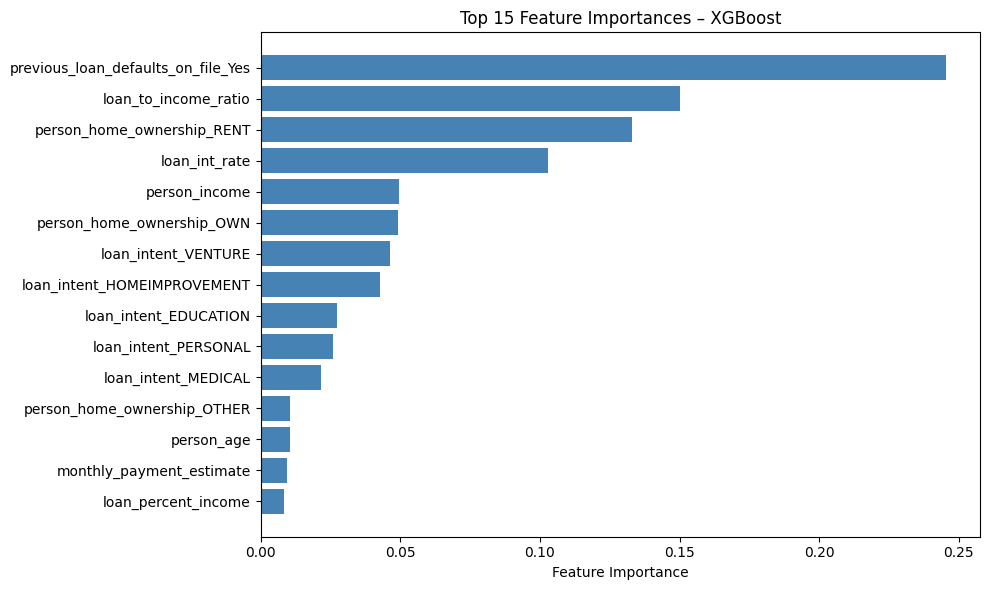

                           Feature  Importance
previous_loan_defaults_on_file_Yes    0.245350
              loan_to_income_ratio    0.150026
        person_home_ownership_RENT    0.132940
                     loan_int_rate    0.102771
                     person_income    0.049566
         person_home_ownership_OWN    0.049122
               loan_intent_VENTURE    0.046270
       loan_intent_HOMEIMPROVEMENT    0.042586
             loan_intent_EDUCATION    0.027347
              loan_intent_PERSONAL    0.025995
               loan_intent_MEDICAL    0.021744
       person_home_ownership_OTHER    0.010630
                        person_age    0.010448
          monthly_payment_estimate    0.009308
               loan_percent_income    0.008227


In [158]:
import pandas as pd

xgb_model = results['XGBoost']

importance_df = pd.DataFrame({
    'Feature'   : x_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances – XGBoost')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))